<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A0%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

На базе баскетбольных матчей добейтесь средней абсолютной ошибки 17 и менее очков.

### Подготовка  

In [2]:
# Загрузка из google облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv', None, quiet=True)

# Библиотека для работы с базами
import pandas as pd
df = pd.read_csv('basketball.csv', encoding= 'cp1251', sep=';', header=0, index_col=0) # Загружаем базу
df.head()

,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


Извлекаем текстовые данные из колонки `info` таблицы, помещаем в переменную `data_text`. Выводим длину списка:

In [3]:
data_text = df['info'].values #

len(data_text) #

52450

Задаем максимальное кол-во слов в словаре, помещаем в переменную все символы, которые хотим вычистить из текста.

 Токенизируем текстовые данные:

In [4]:
# Импортируем токенайзер
from tensorflow.keras.preprocessing.text import Tokenizer

maxWordsCount = 5000

sim_for_del='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer (num_words=maxWordsCount,
                       filters=sim_for_del,
                       lower=True,
                       split=' ',
                       oov_token='unknown',
                       char_level=False)

tokenizer.fit_on_texts(data_text)

In [5]:
# Переводим в Эмбеддинг пространство
Sequences = tokenizer.texts_to_sequences(data_text)

# Вариант  Bag of Words
xBOW_text = tokenizer.sequences_to_matrix(Sequences)

Преобразуем данные в numpy, подготовим наборы для обучения:

In [6]:
# Библиотека работы с массивами
import numpy as np

xTrain = np.array(df[['Ком. 1','Ком. 2', 'Минута', 'Секунда','ftime']].astype('int'))
yTrain = np.array(df['fcount'].astype('int'))

In [7]:
print(xTrain.shape)
print(yTrain.shape)
print(xBOW_text.shape)

(52450, 5)
(52450,)
(52450, 5000)


In [8]:
# Масштабирование данных
from sklearn.preprocessing import StandardScaler
# Для нормализации данных используется готовый инструмент
y_scaler = StandardScaler()
y_train = np.expand_dims(yTrain, axis=1)
print(y_train.shape)
# Нормализация выходных данных по стандартному нормальному распределению
y_train_scaled = y_scaler.fit_transform(y_train)
# Проверка нормализации
print(y_train_scaled.shape)
print(f'Оригинальное значение:  {y_train[1, 0]}')
print(f'Нормированное значение: {y_train_scaled[1, 0]}')

# Вывод границ ненормализованных и нормализованных данных
print(y_train.mean(), y_train.std())
print(y_train_scaled.mean(), y_train_scaled.std())

(52450, 1)
(52450, 1)
Оригинальное значение:  81
Нормированное значение: -2.8372177369594733
151.62581506196378 24.8926313063482
-9.862251890054394e-17 1.0


In [9]:
# Функция по проверке ошибки

def check_MAE_predictl_DubbleInput (model,
                                    x_data,
                                    x_data_text,
                                    y_data_not_scaled,
                                    plot=False):

  mae = 0 # Инициализируем начальное значение ошибки
  y_pred = (model.predict([x_data,x_data_text])).squeeze()

  for n in range (0,len(x_data)):
    mae += abs(y_data_not_scaled[n] - y_pred[n]) # Увеличиваем значение ошибки для текущего элемента
  mae /= len(x_data) # Считаем среднее значение
  print('Среднаяя абслолютная ошибка {:.3f} очков это {:.3f}% от общей выборки в {} игры'.format(mae, (mae/y_data_not_scaled.mean(axis=0))*100,len(x_data)))

  if plot:
     plt.scatter(y_data_not_scaled, y_pred)
     plt.xlabel('Правильные значение')
     plt.ylabel('Предсказания')
     plt.axis('equal')
     plt.xlim(plt.xlim())
     plt.ylim(plt.ylim())
     plt.plot([0, 250], [0, 250])
     plt.show()

In [10]:
# ваше решение
def on_epoch_end_custom(epoch, logs=None):
    model_final_scaled = model_final
    xTrain_scaled = xTrain
    check_MAE_predictl_DubbleInput(model_final_scaled,xTrain_scaled,xBOW_text,yTrain,plot=True)

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, Input, concatenate
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam, Adadelta, SGD, Adagrad, RMSprop

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Масштабирование данных
from sklearn.preprocessing import StandardScaler

# Загрузка датасетов из облака google
import gdown

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Метрики для расчета ошибок
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline
from keras.callbacks import LambdaCallback

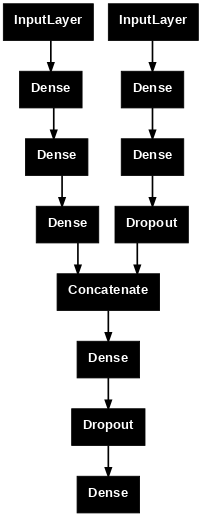

In [11]:
input1 = Input((xTrain.shape[1],))
input2 = Input((xBOW_text.shape[1],))


x1 = input1                               # Ветка 1
x1 = Dense(128, activation="relu")(x1)
x1 = Dense(1000, activation="tanh")(x1)
x1 = Dense(100, activation="relu")(x1)

x2 = input2                               # Ветка 2
x2 = Dense(20, activation="relu")(x2)
x2 = Dense(500, activation="relu")(x2)
x2 = Dropout(0.3)(x2)


x = concatenate([x1, x2])             # Объединение трех веток

x = Dense(15, activation='relu')(x)       # Промежуточный слой
x = Dropout(0.5)(x)
x = Dense(1, activation='linear')(x)      # Финальный регрессирующий нейрон

# В Model передаются входы и выход
model_final = Model((input1, input2), x)
utils.plot_model(model_final, dpi=60)

In [16]:
from tensorflow.keras import backend as K
import tensorflow as tf

def custom_loss(y_true, y_pred):
    mae = K.abs(1 - (K.abs(tf.divide(y_pred,y_true+0.1))))
    return mae

def mae_loss(y_true, y_pred):
    mae = K.mean(K.abs(y_true - (y_pred-30)))
    return mae

model_final.compile(optimizer=Adam(learning_rate=1e-3), loss=mae_loss, metrics=['mae'])
pltMae = LambdaCallback(on_epoch_end=on_epoch_end_custom)

Epoch 1/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 14.765 очков это 9.738% от общей выборки в 52450 игры


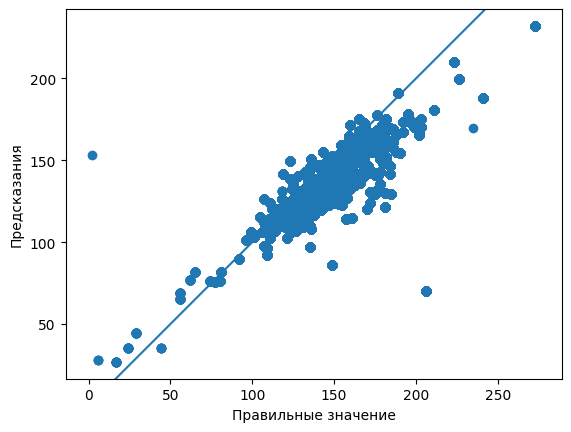

175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - loss: 63.7006 - mae: 55.2671 - val_loss: 49.8449 - val_mae: 23.7944
Epoch 2/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Среднаяя абслолютная ошибка 11.292 очков это 7.447% от общей выборки в 52450 игры


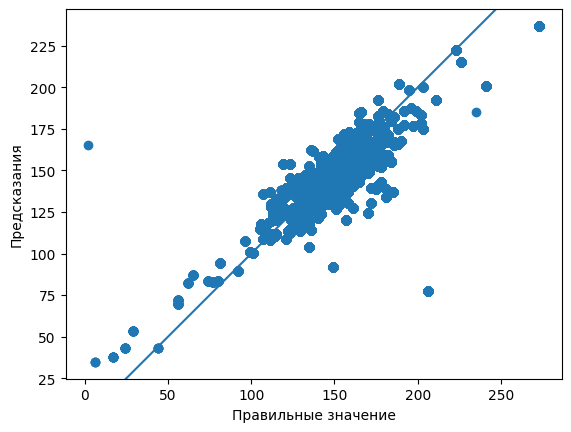

175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 63.8436 - mae: 55.3215 - val_loss: 40.8787 - val_mae: 20.3335
Epoch 3/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.998 очков это 7.253% от общей выборки в 52450 игры


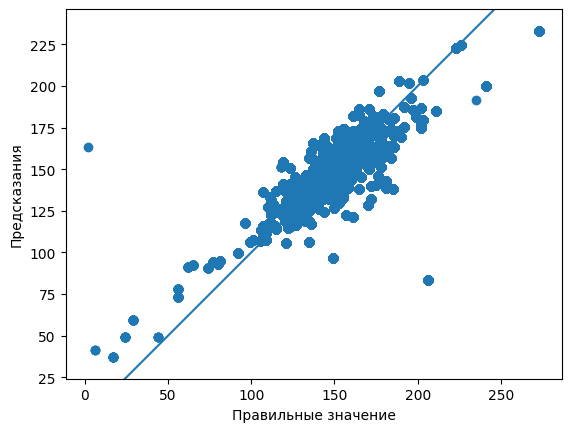

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 63.0062 - mae: 54.7775 - val_loss: 39.7033 - val_mae: 18.6863
Epoch 4/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 13.107 очков это 8.644% от общей выборки в 52450 игры


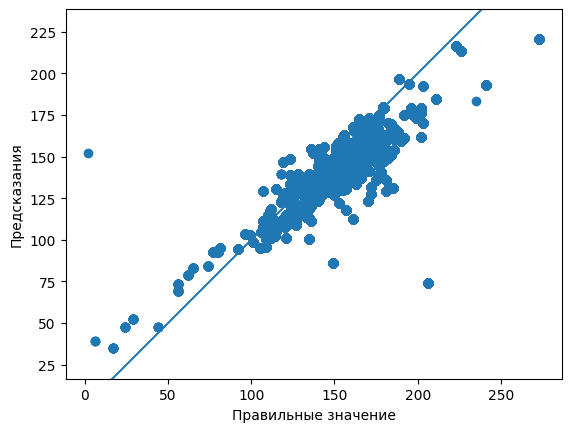

175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 63.3864 - mae: 55.6330 - val_loss: 46.9275 - val_mae: 21.7125
Epoch 5/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.319 очков это 8.125% от общей выборки в 52450 игры


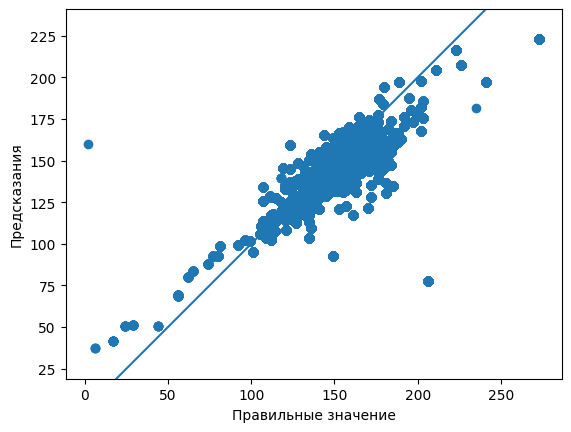

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 62.9561 - mae: 55.5996 - val_loss: 44.4595 - val_mae: 21.2243
Epoch 6/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 11.693 очков это 7.712% от общей выборки в 52450 игры


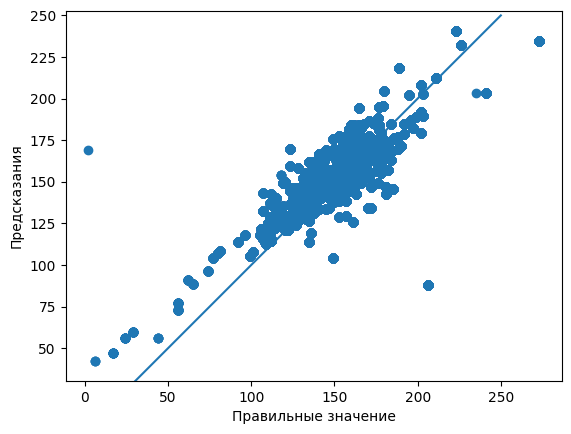

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 63.2007 - mae: 54.9327 - val_loss: 35.0634 - val_mae: 18.3948
Epoch 7/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.114 очков это 7.989% от общей выборки в 52450 игры


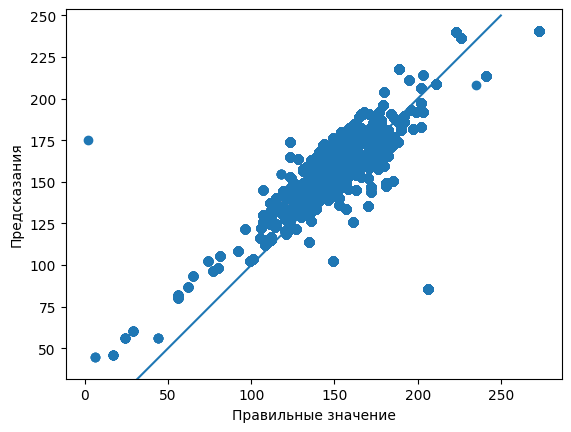

175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 62.9868 - mae: 55.9848 - val_loss: 32.5589 - val_mae: 18.0596
Epoch 8/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.964 очков это 7.231% от общей выборки в 52450 игры


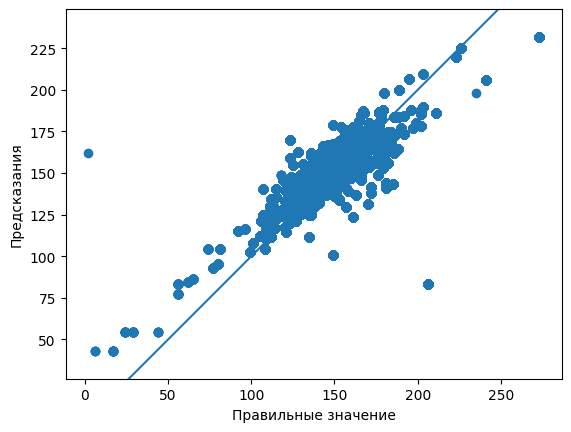

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 63.2934 - mae: 56.2264 - val_loss: 36.6448 - val_mae: 18.1515
Epoch 9/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 10.591 очков это 6.985% от общей выборки в 52450 игры


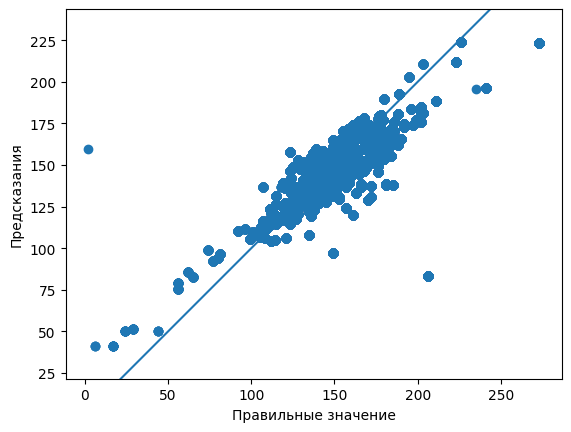

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 63.5250 - mae: 55.9700 - val_loss: 40.9270 - val_mae: 18.3456
Epoch 10/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 10.084 очков это 6.650% от общей выборки в 52450 игры


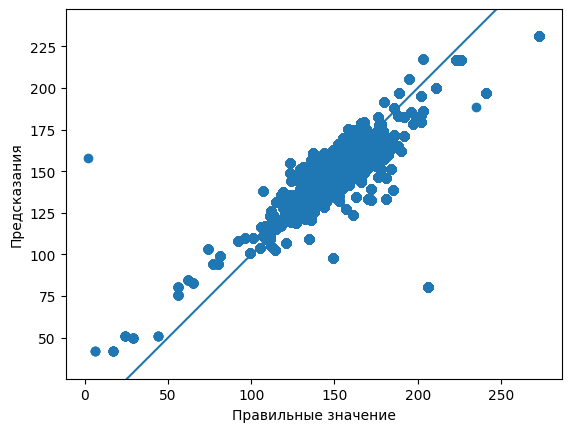

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 62.9569 - mae: 55.8966 - val_loss: 38.9235 - val_mae: 18.0515
Epoch 11/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.621 очков это 8.324% от общей выборки в 52450 игры


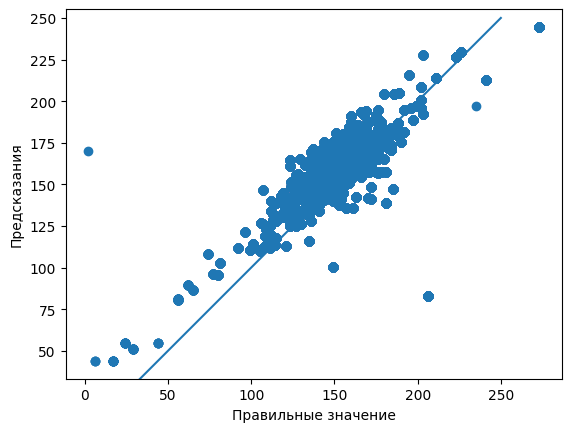

175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 63.1002 - mae: 55.2277 - val_loss: 30.2812 - val_mae: 19.3186
Epoch 12/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 11.603 очков это 7.653% от общей выборки в 52450 игры


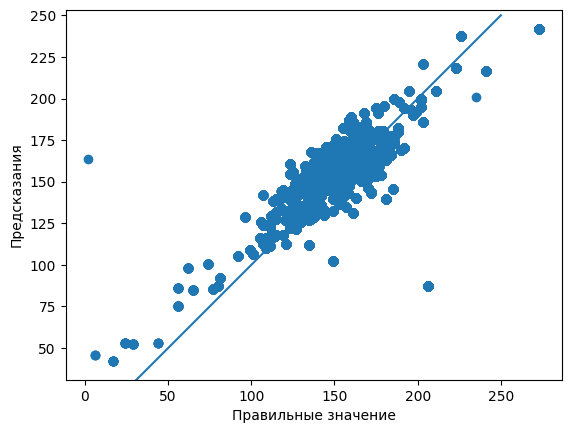

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 63.0881 - mae: 56.5927 - val_loss: 31.9988 - val_mae: 18.0692
Epoch 13/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 14.643 очков это 9.658% от общей выборки в 52450 игры


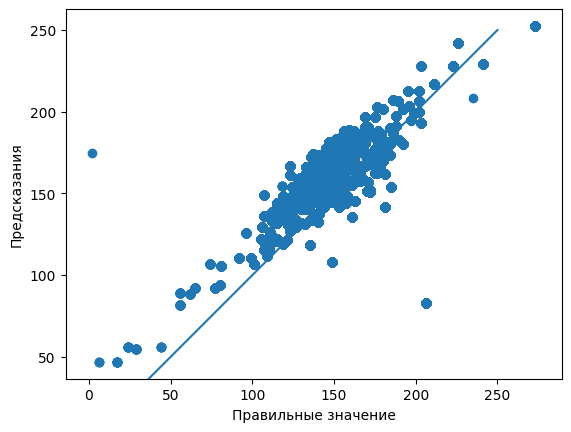

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 63.0788 - mae: 57.2475 - val_loss: 26.6590 - val_mae: 19.5444
Epoch 14/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 13.513 очков это 8.912% от общей выборки в 52450 игры


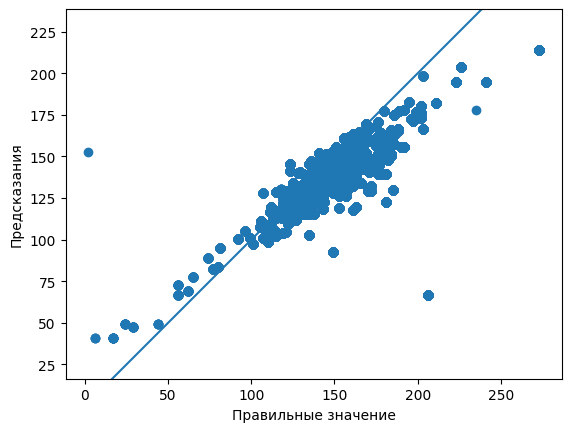

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 62.7449 - mae: 57.4459 - val_loss: 47.2679 - val_mae: 20.9203
Epoch 15/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 13.857 очков это 9.139% от общей выборки в 52450 игры


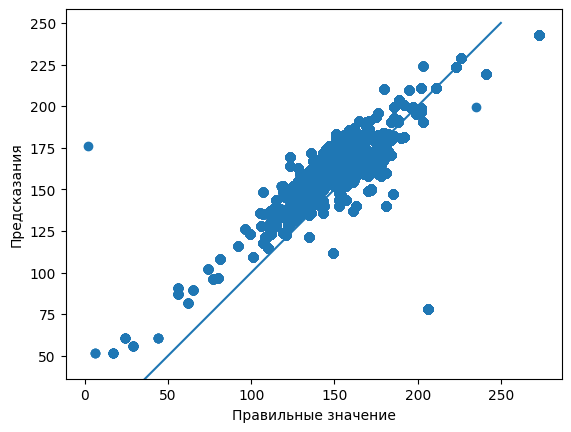

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 62.7280 - mae: 54.1194 - val_loss: 28.2777 - val_mae: 19.3815
Epoch 16/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.504 очков это 6.928% от общей выборки в 52450 игры


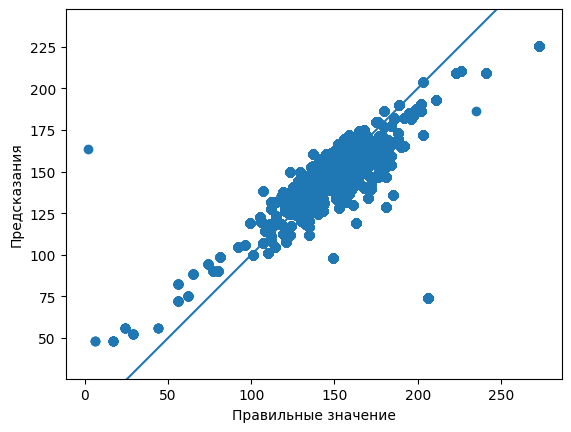

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 63.0079 - mae: 58.2197 - val_loss: 39.5305 - val_mae: 18.1725
Epoch 17/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.357 очков это 8.150% от общей выборки в 52450 игры


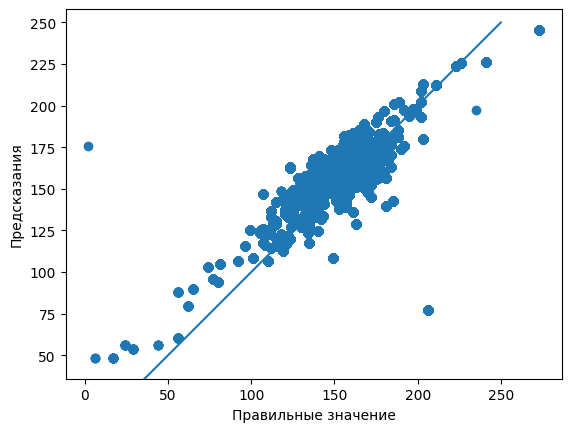

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 62.3690 - mae: 54.9396 - val_loss: 30.9226 - val_mae: 18.6740
Epoch 18/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.722 очков это 7.071% от общей выборки в 52450 игры


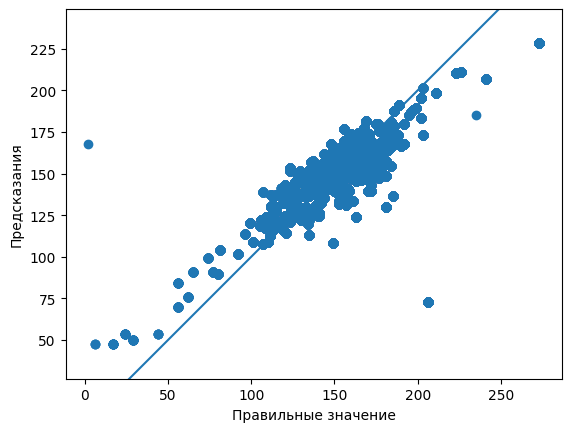

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 62.5120 - mae: 54.0211 - val_loss: 37.9287 - val_mae: 17.5394
Epoch 19/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 11.009 очков это 7.260% от общей выборки в 52450 игры


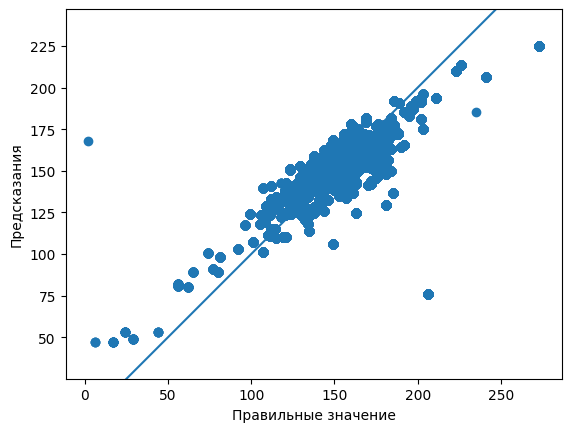

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 62.8548 - mae: 54.5364 - val_loss: 38.0316 - val_mae: 17.2245
Epoch 20/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.512 очков это 8.252% от общей выборки в 52450 игры


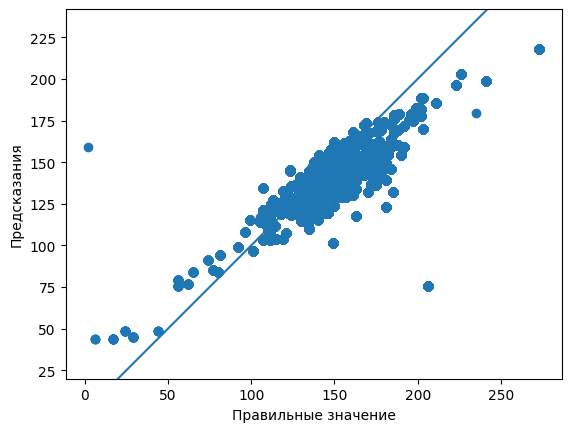

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 62.7235 - mae: 55.5301 - val_loss: 44.4872 - val_mae: 19.5196
Epoch 21/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 11.059 очков это 7.294% от общей выборки в 52450 игры


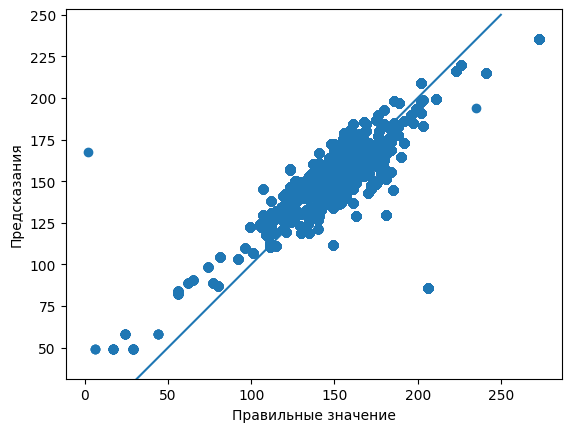

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 62.2186 - mae: 54.7051 - val_loss: 34.1215 - val_mae: 16.7146
Epoch 22/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 13.694 очков это 9.032% от общей выборки в 52450 игры


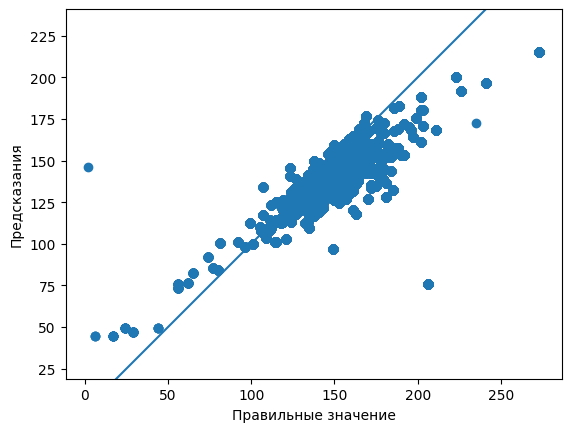

175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 62.4325 - mae: 54.9089 - val_loss: 47.6569 - val_mae: 20.6455
Epoch 23/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 14.459 очков это 9.536% от общей выборки в 52450 игры


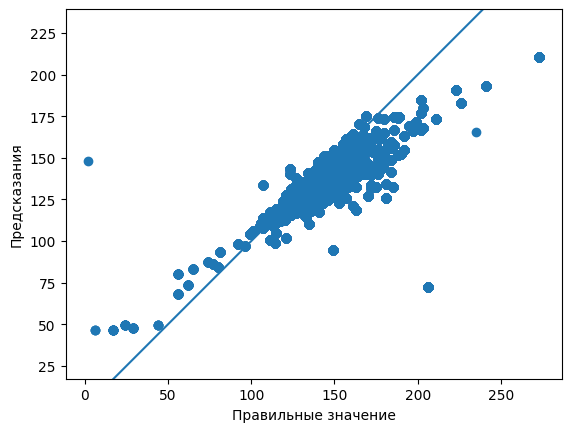

175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 62.2709 - mae: 54.2354 - val_loss: 48.5504 - val_mae: 21.2400
Epoch 24/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.858 очков это 8.480% от общей выборки в 52450 игры


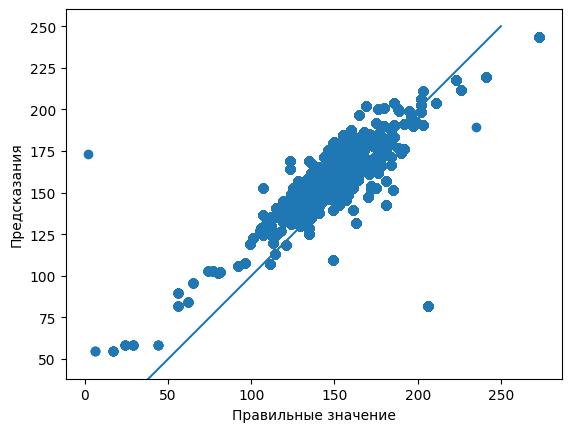

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 61.7151 - mae: 52.9331 - val_loss: 28.9790 - val_mae: 17.9241
Epoch 25/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 15.239 очков это 10.050% от общей выборки в 52450 игры


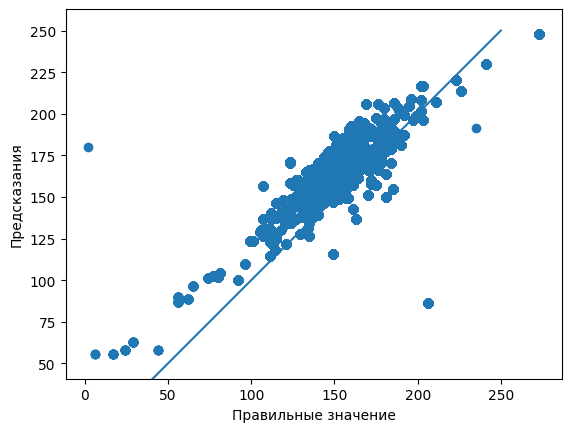

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 62.2697 - mae: 56.3620 - val_loss: 25.3769 - val_mae: 19.0235
Epoch 26/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 13.065 очков это 8.616% от общей выборки в 52450 игры


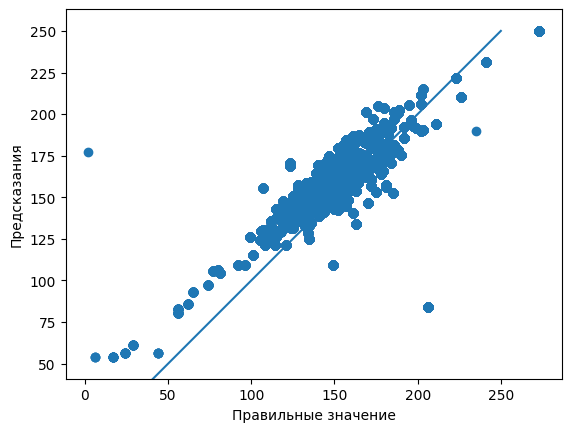

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 62.3032 - mae: 56.3418 - val_loss: 28.3725 - val_mae: 17.3398
Epoch 27/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 12.347 очков это 8.143% от общей выборки в 52450 игры


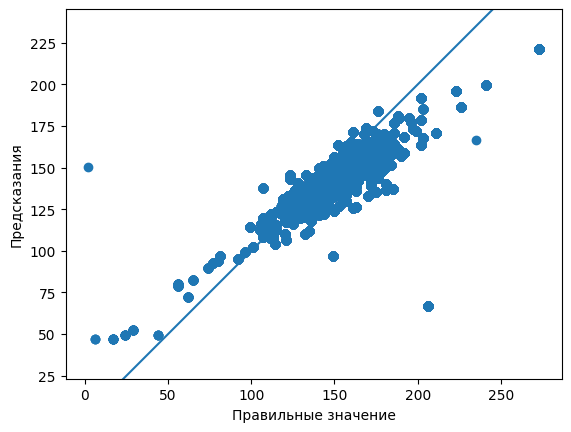

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 62.6127 - mae: 55.8965 - val_loss: 44.4100 - val_mae: 18.6079
Epoch 28/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.346 очков это 6.824% от общей выборки в 52450 игры


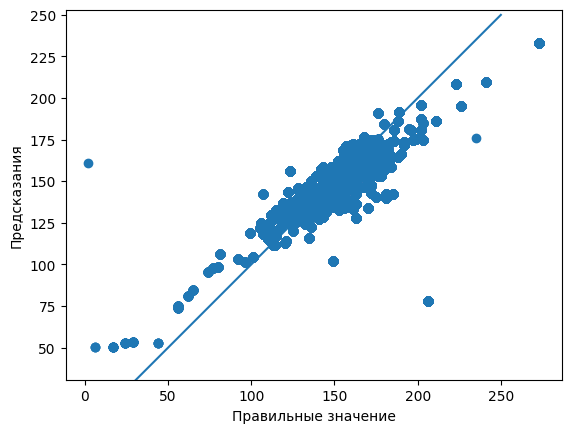

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 62.2887 - mae: 54.6216 - val_loss: 38.9776 - val_mae: 17.2272
Epoch 29/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Среднаяя абслолютная ошибка 10.148 очков это 6.692% от общей выборки в 52450 игры


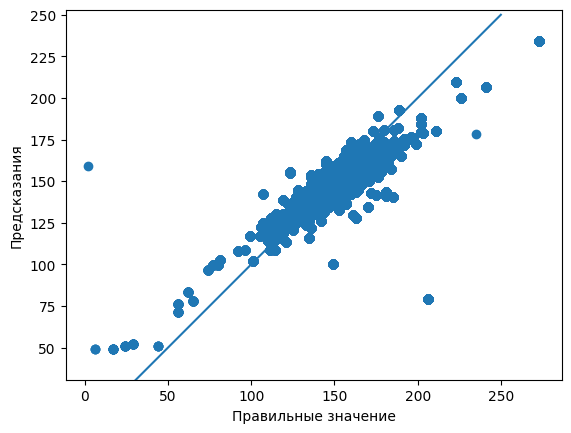

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 61.6613 - mae: 54.6586 - val_loss: 39.3984 - val_mae: 17.2501
Epoch 30/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 13.064 очков это 8.616% от общей выборки в 52450 игры


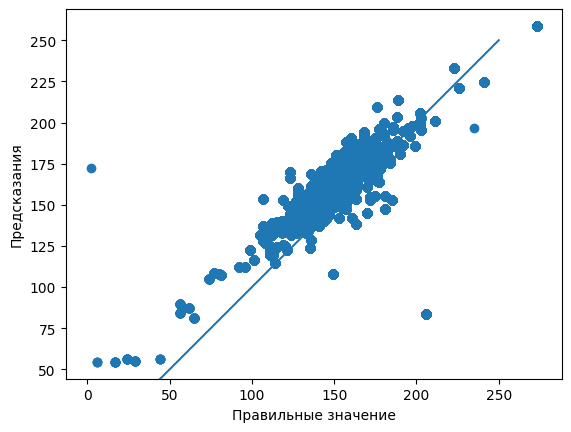

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 61.4598 - mae: 53.5568 - val_loss: 27.7327 - val_mae: 18.7982
Epoch 31/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.458 очков это 6.897% от общей выборки в 52450 игры


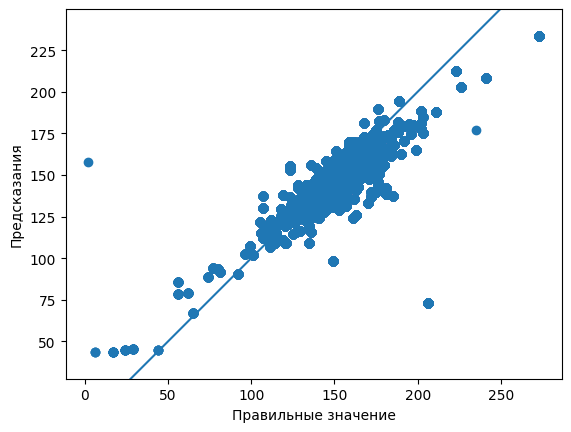

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 62.3032 - mae: 55.8183 - val_loss: 41.5089 - val_mae: 18.2682
Epoch 32/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 10.878 очков это 7.174% от общей выборки в 52450 игры


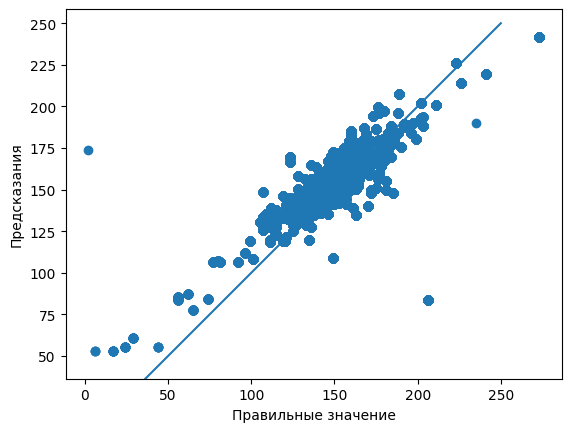

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 62.1187 - mae: 54.3302 - val_loss: 31.4408 - val_mae: 17.8498
Epoch 33/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 9.696 очков это 6.395% от общей выборки в 52450 игры


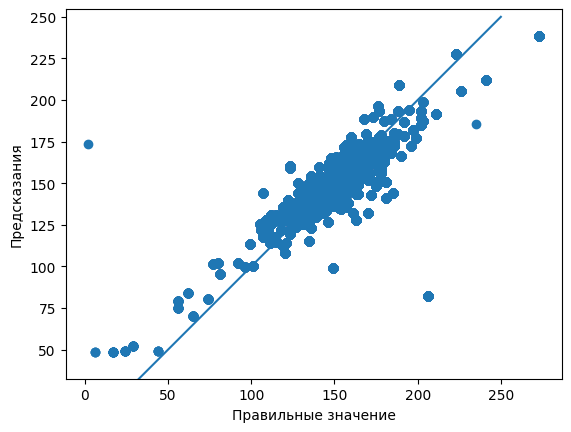

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 61.2817 - mae: 53.5144 - val_loss: 36.9746 - val_mae: 17.1785
Epoch 34/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Среднаяя абслолютная ошибка 10.913 очков это 7.197% от общей выборки в 52450 игры


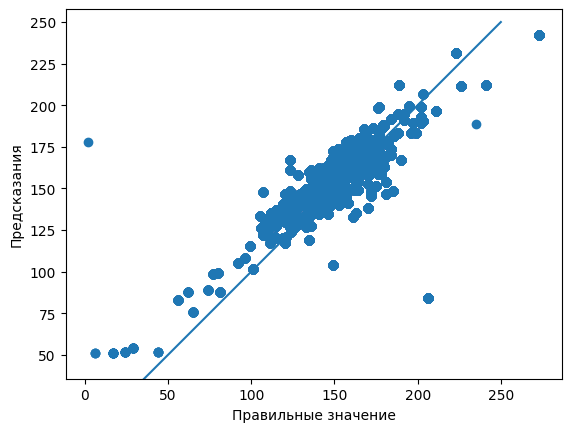

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 61.2479 - mae: 53.7687 - val_loss: 32.4812 - val_mae: 17.1269
Epoch 35/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 13.452 очков это 8.872% от общей выборки в 52450 игры


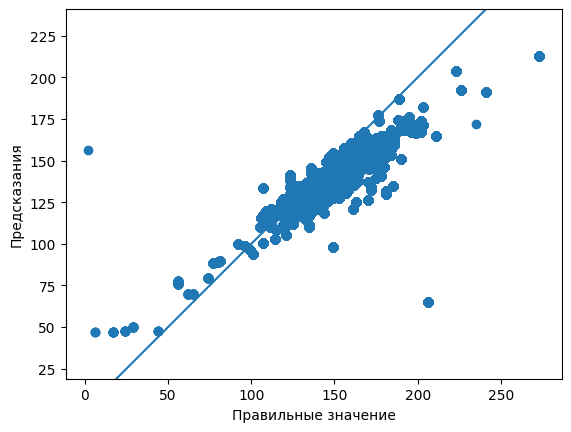

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 61.0003 - mae: 54.7497 - val_loss: 46.9815 - val_mae: 19.9883
Epoch 36/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 11.004 очков это 7.258% от общей выборки в 52450 игры


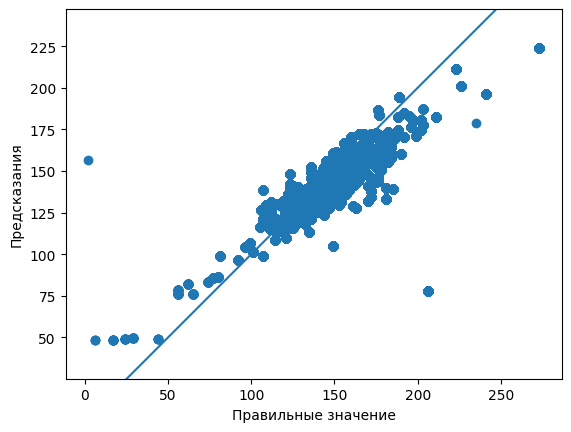

175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 61.5218 - mae: 52.5784 - val_loss: 41.5188 - val_mae: 17.7643
Epoch 37/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 9.539 очков это 6.291% от общей выборки в 52450 игры


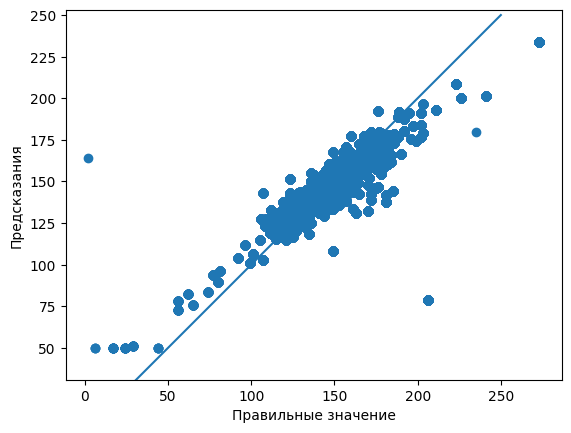

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - loss: 61.2150 - mae: 54.3989 - val_loss: 38.0162 - val_mae: 16.2988
Epoch 38/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 10.484 очков это 6.914% от общей выборки в 52450 игры


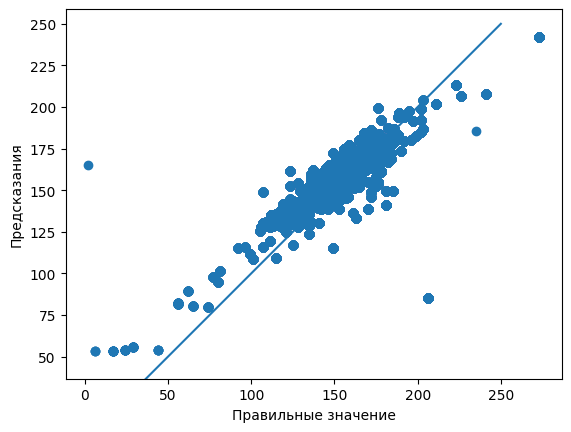

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 61.5901 - mae: 54.9040 - val_loss: 31.7603 - val_mae: 16.9367
Epoch 39/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Среднаяя абслолютная ошибка 10.507 очков это 6.929% от общей выборки в 52450 игры


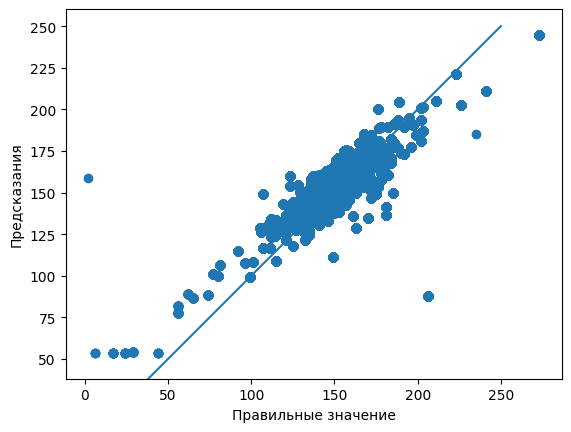

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 61.7819 - mae: 56.7635 - val_loss: 32.6554 - val_mae: 16.9759
Epoch 40/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 9.517 очков это 6.277% от общей выборки в 52450 игры


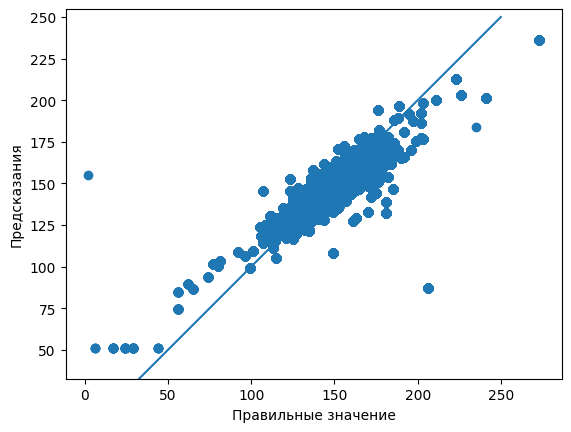

175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 61.3310 - mae: 53.8634 - val_loss: 37.2531 - val_mae: 15.7551
Epoch 41/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 12.380 очков это 8.165% от общей выборки в 52450 игры


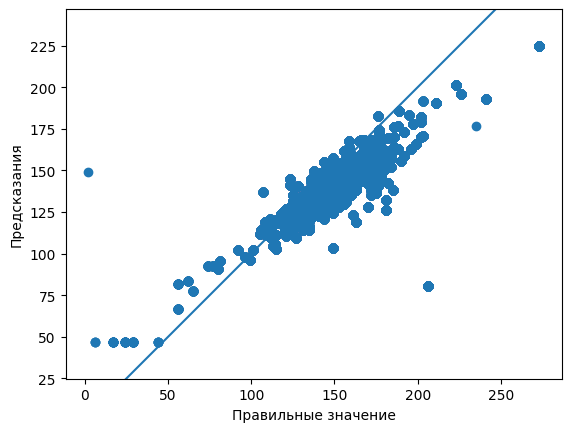

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 61.3386 - mae: 56.4238 - val_loss: 44.7744 - val_mae: 18.5250
Epoch 42/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 12.954 очков это 8.544% от общей выборки в 52450 игры


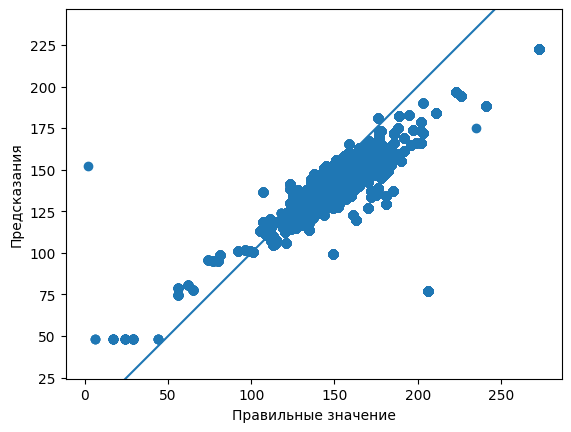

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 60.8534 - mae: 51.4992 - val_loss: 45.8006 - val_mae: 19.0984
Epoch 43/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Среднаяя абслолютная ошибка 9.688 очков это 6.389% от общей выборки в 52450 игры


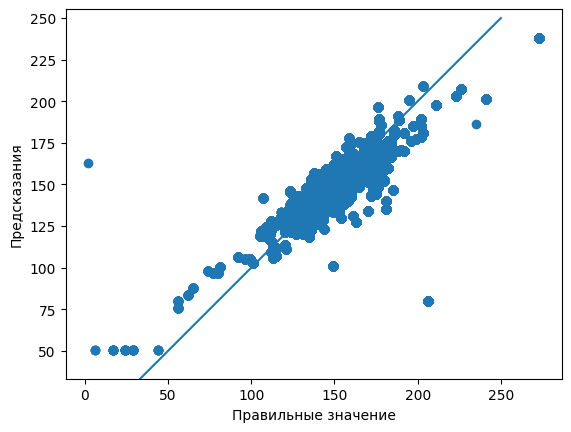

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 60.2593 - mae: 52.2843 - val_loss: 38.0039 - val_mae: 15.9476
Epoch 44/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 9.546 очков это 6.296% от общей выборки в 52450 игры


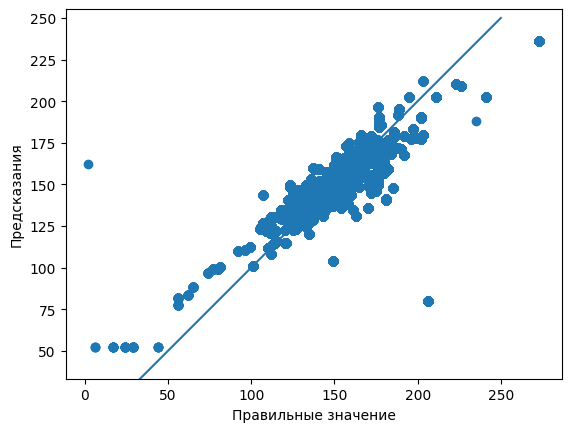

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 60.8896 - mae: 53.1540 - val_loss: 35.4971 - val_mae: 15.8518
Epoch 45/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Среднаяя абслолютная ошибка 12.058 очков это 7.952% от общей выборки в 52450 игры


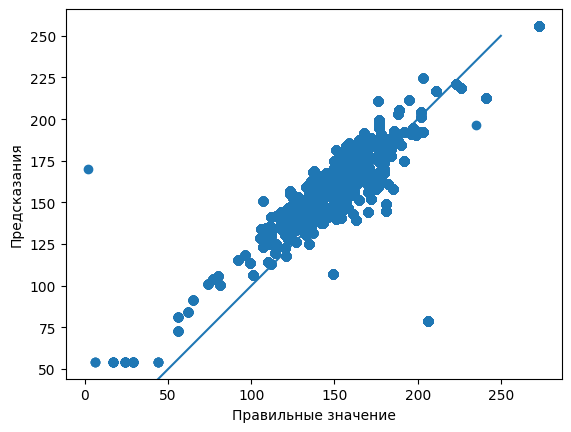

175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 61.4009 - mae: 53.4235 - val_loss: 28.1680 - val_mae: 17.7474
Epoch 46/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 9.834 очков это 6.486% от общей выборки в 52450 игры


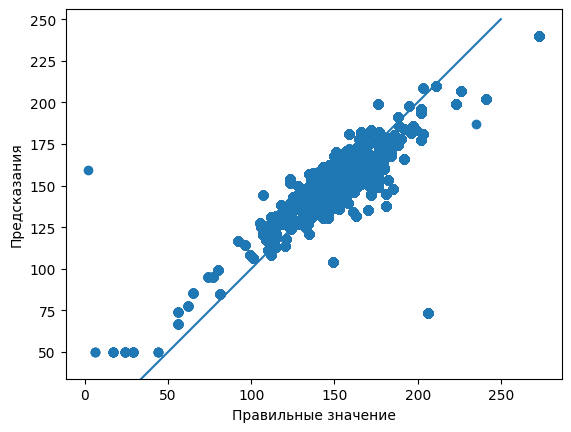

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 61.1773 - mae: 54.9460 - val_loss: 35.3528 - val_mae: 16.0477
Epoch 47/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 12.460 очков это 8.218% от общей выборки в 52450 игры


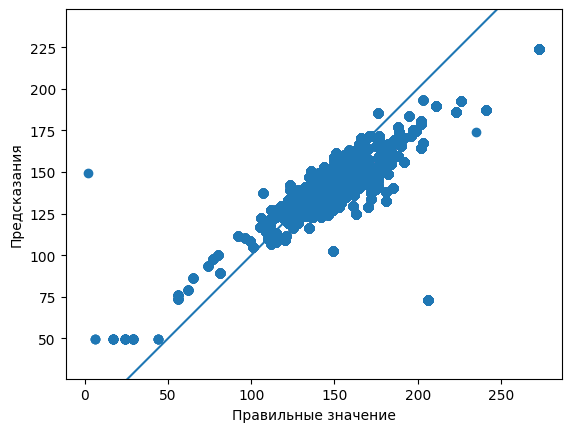

175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 60.2499 - mae: 52.5763 - val_loss: 43.3609 - val_mae: 17.8619
Epoch 48/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Среднаяя абслолютная ошибка 10.410 очков это 6.865% от общей выборки в 52450 игры


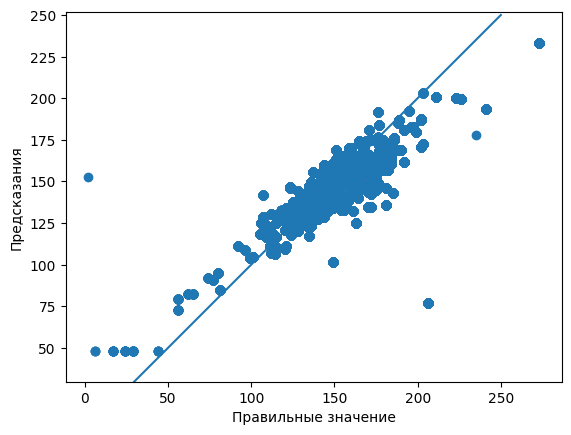

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 60.7052 - mae: 52.2013 - val_loss: 38.7669 - val_mae: 16.7377
Epoch 49/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 10.868 очков это 7.168% от общей выборки в 52450 игры


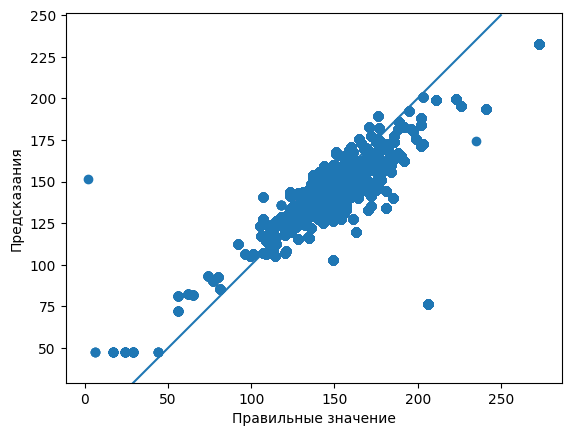

175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 60.4989 - mae: 53.9928 - val_loss: 40.6399 - val_mae: 17.0580
Epoch 50/50
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 10.411 очков это 6.867% от общей выборки в 52450 игры


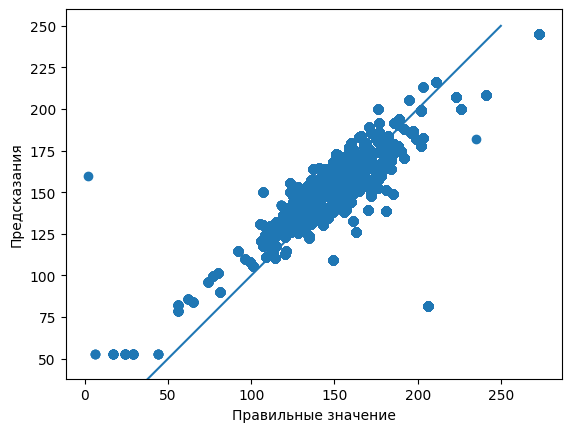

175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 60.6117 - mae: 52.8028 - val_loss: 32.8063 - val_mae: 16.7123


In [17]:
history = model_final.fit([xTrain, xBOW_text],
                           yTrain,
                           batch_size=256,
                           epochs=50,
                           validation_split=0.15,
                           verbose=1, callbacks=[pltMae])

Для решения задачи требуются знания по теме `Callbacks`, пожалуйста, изучите раздел:

---
Дополнителная информация: ([База знаний УИИ – **«Callbacks»**](https://colab.research.google.com/drive/1COE1R3kFhRlxPm9X6hQMvjKoiFFt83xW?usp=sharing))

---